In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('genetherapy.csv')

df_new = pd.DataFrame()
df_new['A'] = df[df['Therapy'] == 'A']['expr'].reset_index(drop=True)
df_new['B'] = df[df['Therapy'] == 'B']['expr'].reset_index(drop=True)
df_new['C'] = df[df['Therapy'] == 'C']['expr'].reset_index(drop=True)
df_new['D'] = df[df['Therapy'] == 'D']['expr'].reset_index(drop=True)


grand_mean = round(df_new.mean().mean(), 1)
print(f'grand_mean = {grand_mean}')

sst = sum(round(((df_new.mean() - grand_mean) ** 2), 1))
print(f'sst = {sst}')

df_all = len(df_new) * df_new.columns.size - df_new.columns.size
print(f'df_all = {df_all}')

ssb = sum(round( (len(df_new)*(df_new.mean() - grand_mean) ** 2), 1) )
print(f'ssb = {ssb}')

df_bg = df_new.columns.size - 1
Ms_bg = ssb/df_bg

ssw = round(((df_new - df_new.mean())**2).sum().sum(), 1)
print(f'ssw = {ssw}')

Ms_wg = round(ssw/df_all, 2)
print(Ms_wg)

F = round(Ms_bg/Ms_wg, 3)
print(f'F = {F}')




grand_mean = 96.3
sst = 37.3
df_all = 56
ssb = 560.7
ssw = 1302.3
23.26
F = 8.035


P: 0.00015431952285710232


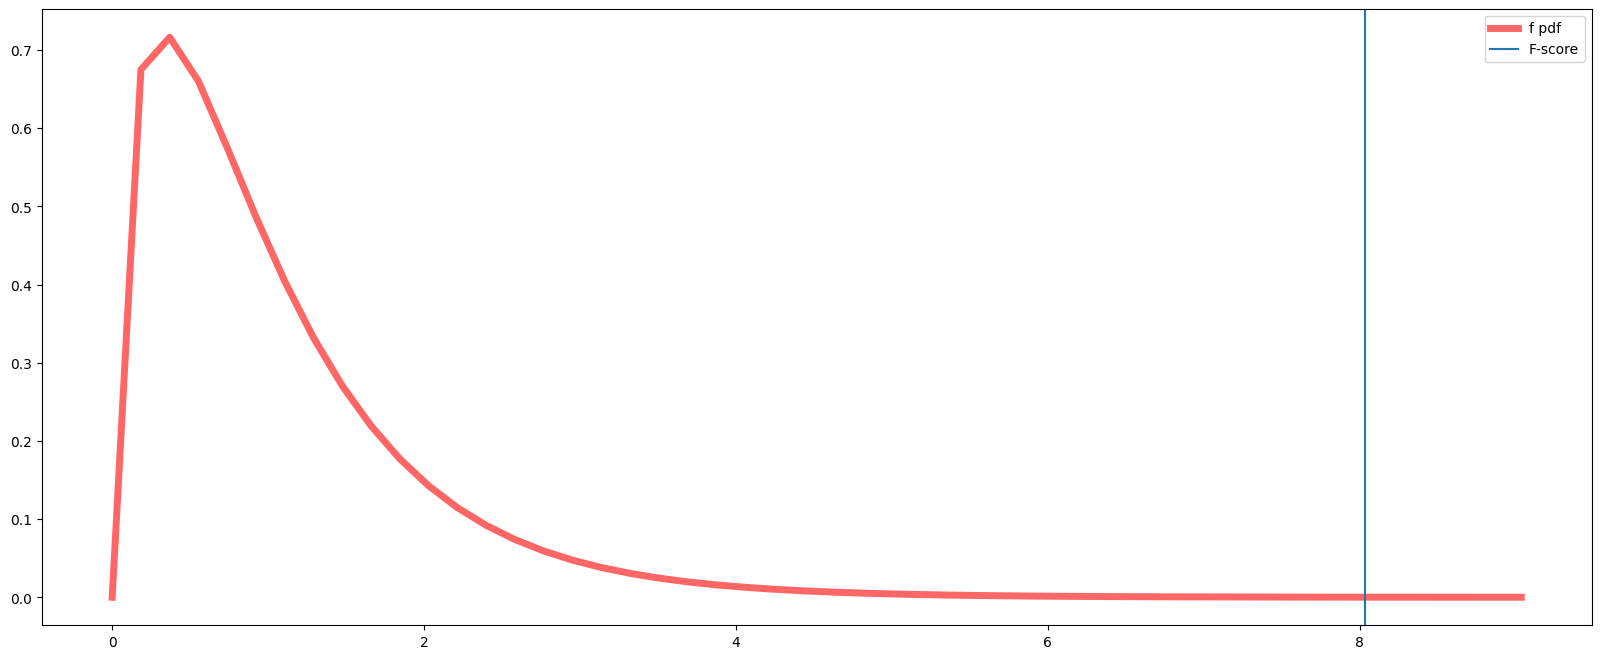

In [ ]:
from scipy.stats import f
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

dfn, dfd = df_bg, df_all

x = np.linspace(0, F+1)

plt.plot(x, f.pdf(x, dfn, dfd),'r-', lw=5, alpha=0.6, label='f pdf')

plt.axvline(x=F, label='F-score')

plt.legend()



print("P:", f.pdf(F, dfn, dfd))

In [ ]:
dov_int = df_new.mean() + 1.96*(np.std(df_new)/df_new.count()**0.5)
print(dov_int)

A    101.769946
B    101.681785
C     96.939106
D     94.159553
dtype: float64


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [ ]:
import matplotlib.pyplot as plt

means = df_new.mean()
stds = df_new.std(ddof=1)
ns = df_new.count()
z = 1.96

ci_lower = means - z * (stds / np.sqrt(ns))
ci_upper = means + z * (stds / np.sqrt(ns))

ci_df = pd.DataFrame({
    'mean': means,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper
})

print(ci_df)

A    15
B    15
C    15
D    15
dtype: int64
        mean   ci_lower    ci_upper
A  99.733333  97.625239  101.841427
B  98.800000  95.817069  101.782931
C  94.400000  91.771776   97.028224
D  92.333333  90.443016   94.223650


<ipython-input-76-a907ac245158>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_new[col].dropna() for col in df_new.columns], labels=df_new.columns)


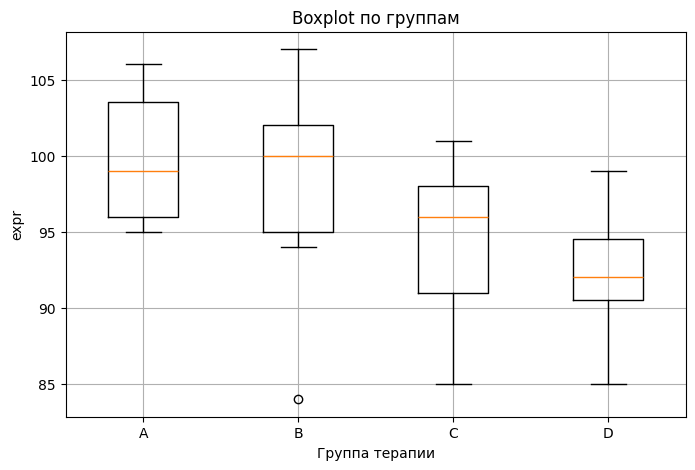

In [ ]:
# Построение боксплота
plt.figure(figsize=(8, 5))
plt.boxplot([df_new[col].dropna() for col in df_new.columns], labels=df_new.columns)
plt.title('Boxplot по группам')
plt.ylabel('expr')
plt.xlabel('Группа терапии')
plt.grid(True)
plt.show()
